# Entrega 3 — Chunking de Manifestações Longas

**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**
Aluno: Pedro Ernesto

Objetivo: dividir as 5 manifestações mais longas em *chunks* com o `RecursiveCharacterTextSplitter` do LangChain, testar configurações diferentes de `(chunk_size, chunk_overlap)` e responder:

1. Como o overlap influencia a coesão semântica entre chunks consecutivos?
2. Qual configuração preserva melhor o sentido das denúncias?
3. No espaço 2D (PCA / t-SNE), os chunks de uma mesma manifestação ficam próximos?

**Por que chunking?** O modelo `paraphrase-multilingual-MiniLM-L12-v2` trunca a entrada em 128 tokens (~ 400 a 500 caracteres em português). Uma manifestação de 800 caracteres indexada como um bloco só perde o final do texto, que muitas vezes contém o pedido concreto do cidadão. Além disso, um texto longo que fala de três problemas vira um embedding "médio" que não representa bem nenhum dos três.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid")
Path("resultados").mkdir(exist_ok=True)

df = pd.read_json("manifestacoes.json")
df["n_chars"] = df["texto"].str.len()
longas = df.sort_values("n_chars", ascending=False).head(5).reset_index(drop=True)
longas[["id", "categoria_oficial", "n_chars"]]

,id,categoria_oficial,n_chars
0,M033,educação,799
1,M006,saúde,778
2,M040,meio ambiente,775
3,M015,segurança,775
4,M024,infraestrutura,746


In [2]:
MODELO = "paraphrase-multilingual-MiniLM-L12-v2"
modelo = SentenceTransformer(MODELO)
print("limite de tokens do modelo:", modelo.max_seq_length)

# quantos tokens cada manifestação longa realmente tem: se passar do limite, o final do texto é ignorado
tok = modelo.tokenizer
longas["n_tokens"] = longas["texto"].apply(lambda t: len(tok(t)["input_ids"]))
longas[["id", "n_chars", "n_tokens"]]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (190 > 128). Running this sequence through the model will result in indexing errors


limite de tokens do modelo: 128


,id,n_chars,n_tokens
0,M033,799,190
1,M006,778,196
2,M040,775,190
3,M015,775,191
4,M024,746,200


## 1. Configurações de chunking

O `RecursiveCharacterTextSplitter` tenta cortar primeiro em parágrafos (`\n\n`), depois em linhas, depois em espaços, e só por último no meio de palavras. Como as manifestações são um parágrafo só, na prática ele corta em espaços, tentando respeitar `chunk_size`.

Testei também uma lista de separadores com `". "` e `", "` antes do espaço, para os cortes respeitarem frases. O resultado foi inesperado: como o splitter só reaproveita um "pedaço" inteiro do chunk anterior para fazer o overlap, e as frases das manifestações têm 80 a 150 caracteres, um `chunk_overlap=60` simplesmente não cabe em nenhuma frase e o overlap efetivo cai para quase zero (medido: ~2 caracteres em média). Por isso uso os separadores padrão (nível de palavra), em que o overlap funciona como esperado.

Três configurações:

| nome | chunk_size | chunk_overlap | ideia |
|---|---|---|---|
| A | 200 | 0 | chunks pequenos e disjuntos |
| B | 200 | 60 | mesmos chunks, mas com 30% de sobreposição |
| C | 350 | 80 | chunks maiores, próximos do limite de tokens do modelo |

In [3]:
CONFIGS = {"A": (200, 0), "B": (200, 60), "C": (350, 80)}
SEPARADORES = ["\n\n", "\n", " ", ""]   # padrão do LangChain (ver nota acima)

def fatiar(texto, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap,
        separators=SEPARADORES, length_function=len,
    )
    return splitter.split_text(texto)

chunks = []  # uma linha por chunk, por configuração
for nome, (cs, co) in CONFIGS.items():
    for _, row in longas.iterrows():
        for k, c in enumerate(fatiar(row["texto"], cs, co)):
            chunks.append({"config": nome, "id": row["id"], "categoria": row["categoria_oficial"],
                           "k": k, "chunk": c, "n_chars": len(c)})
chunks = pd.DataFrame(chunks)

resumo = chunks.groupby("config").agg(n_chunks=("chunk", "size"), chars_medio=("n_chars", "mean"),
                                       chars_min=("n_chars", "min"), chars_max=("n_chars", "max")).round(1)
resumo["chunks por manifestação"] = chunks.groupby(["config", "id"]).size().groupby("config").mean().round(1)
resumo

,n_chunks,chars_medio,chars_min,chars_max,chunks por manifestação
config,,,,,
A,20,192.9,153,200,4.0
B,29,180.3,68,200,5.8
C,15,308.3,207,350,3.0


In [4]:
# Exemplo concreto: a mesma manifestação nas três configurações
EXEMPLO = longas.loc[0, "id"]
for nome in CONFIGS:
    print(f"\n===== config {nome} {CONFIGS[nome]} — {EXEMPLO} =====")
    for _, r in chunks[(chunks.config == nome) & (chunks.id == EXEMPLO)].iterrows():
        print(f"[{r.k}] ({r.n_chars} chars) {r.chunk}\n")


===== config A (200, 0) — M033 =====
[0] (200 chars) Sou mãe de dois alunos da Escola Municipal Frei Damião, no bairro Funcionários, e quero registrar a situação precária da escola. Os banheiros dos alunos estão interditados desde o meio do ano porque o

[1] (199 chars) encanamento estourou, e as crianças usam o banheiro dos professores em revezamento, gerando filas enormes; muitas evitam beber água para não precisar ir. Os ventiladores não funcionam e, com calor de

[2] (199 chars) quase 35 graus, os alunos ficam sonolentos e passam mal. Faltam carteiras, então alguns assistem aula em pé ou dividindo cadeira. A quadra não tem cobertura e a educação física acontece sob sol forte

[3] (198 chars) ao meio-dia. A direção sempre diz que o pedido foi encaminhado à Secretaria de Educação, mas nada muda. Pedimos vistoria e um cronograma real de reparos, começando pelos banheiros e pela ventilação.


===== config B (200, 60) — M033 =====
[0] (200 chars) Sou mãe de dois alunos da Escola Munici

## 2. Coesão semântica entre chunks consecutivos

Para cada configuração, calculo a similaridade de cosseno entre cada chunk e o chunk seguinte da mesma manifestação. Quanto maior, mais "contínuo" é o documento fatiado.

Também calculo duas métricas complementares que dizem se o sentido do texto foi preservado:

- **fidelidade ao documento**: similaridade média entre cada chunk e o embedding do texto completo (quanto do sentido global cada pedaço carrega);
- **cobertura**: similaridade entre o *chunk mais parecido* e o documento completo (se pelo menos um chunk representa bem a denúncia, a busca semântica ainda a encontra).

In [5]:
E_chunks = modelo.encode(chunks["chunk"].tolist(), normalize_embeddings=True, show_progress_bar=False)
chunks["emb"] = list(E_chunks)
E_docs = dict(zip(longas["id"], modelo.encode(longas["texto"].tolist(), normalize_embeddings=True, show_progress_bar=False)))

linhas = []
for (nome, mid), g in chunks.groupby(["config", "id"]):
    g = g.sort_values("k")
    embs = np.vstack(g["emb"].values)
    consec = [float(embs[i] @ embs[i + 1]) for i in range(len(embs) - 1)]
    fid = embs @ E_docs[mid]
    linhas.append({"config": nome, "id": mid, "n_chunks": len(g),
                   "coesão consecutiva": np.mean(consec) if consec else np.nan,
                   "fidelidade média": fid.mean(), "cobertura (melhor chunk)": fid.max()})
metricas = pd.DataFrame(linhas)
tabela_coesao = metricas.groupby("config")[["n_chunks", "coesão consecutiva", "fidelidade média", "cobertura (melhor chunk)"]].mean().round(3)
tabela_coesao

,n_chunks,coesão consecutiva,fidelidade média,cobertura (melhor chunk)
config,,,,
A,4.0,0.458,0.692,0.887
B,5.8,0.562,0.655,0.887
C,3.0,0.582,0.747,0.963


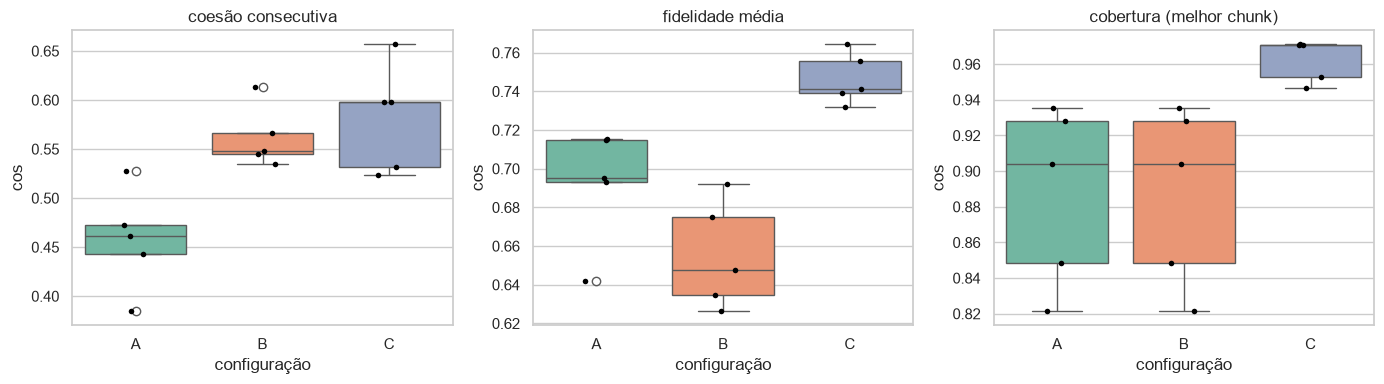

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["coesão consecutiva", "fidelidade média", "cobertura (melhor chunk)"]):
    sns.boxplot(data=metricas, x="config", y=col, ax=ax, palette="Set2", hue="config", legend=False)
    sns.stripplot(data=metricas, x="config", y=col, ax=ax, color="black", size=4)
    ax.set_title(col); ax.set_xlabel("configuração"); ax.set_ylabel("cos")
plt.tight_layout()

### Pergunta 1: como o overlap influencia a coesão?

Comparando **A (200, 0)** com **B (200, 60)**, a única diferença é o overlap. Com sobreposição, chunks consecutivos compartilham literalmente as mesmas ~60 caracteres (normalmente o fim de uma frase e o começo da próxima), e isso aparece diretamente como aumento da coesão consecutiva (de 0.46 em A para 0.56 em B, na média das cinco manifestações). O efeito é esperado: parte do vetor de cada chunk passa a ser calculado sobre texto idêntico ao vizinho.

O overlap não muda o número de "ideias" no texto, mas diminui o risco de uma frase importante ser cortada ao meio entre dois chunks e não ficar inteira em nenhum deles. O custo é redundância: mais chunks para armazenar e um pequeno viés na busca, porque um trecho repetido em dois chunks conta duas vezes no ranking. Não testei overlaps maiores; a expectativa é que, acima de ~30% do chunk_size, o ganho de coesão diminua e só a redundância cresça.

### Pergunta 2: qual configuração preserva melhor o sentido das denúncias?

A resposta depende do que se quer preservar. A configuração **C (350, 80)** gera chunks maiores, cada um cobrindo um "tema" completo da denúncia (por exemplo, em M006: um chunk sobre a falta de remédios e outro sobre a agenda de consultas), e por isso tem a maior *fidelidade média* ao documento (0.75, contra 0.69 em A e 0.65 em B) e a maior cobertura (0.96). A configuração **B (200, 60)** gera chunks mais específicos, o que favorece a busca por um detalhe pontual (alguém buscando "falta de insulina" encontra exatamente o pedaço certo) e tem coesão consecutiva maior que A.

Para a Ouvidoria a escolha recomendada é **C**: chunks de ~350 caracteres ficam abaixo do limite de 128 tokens do modelo (então nada é truncado) e ainda são grandes o suficiente para conter sujeito + problema + local. Exemplos concretos aparecem na célula de impressão acima e são discutidos no relatório.

## 3. Visualização 2D dos chunks (PCA e t-SNE)

A    0.195
B    0.203
C    0.273
Name: silhueta (cos) por manifestação, dtype: float64

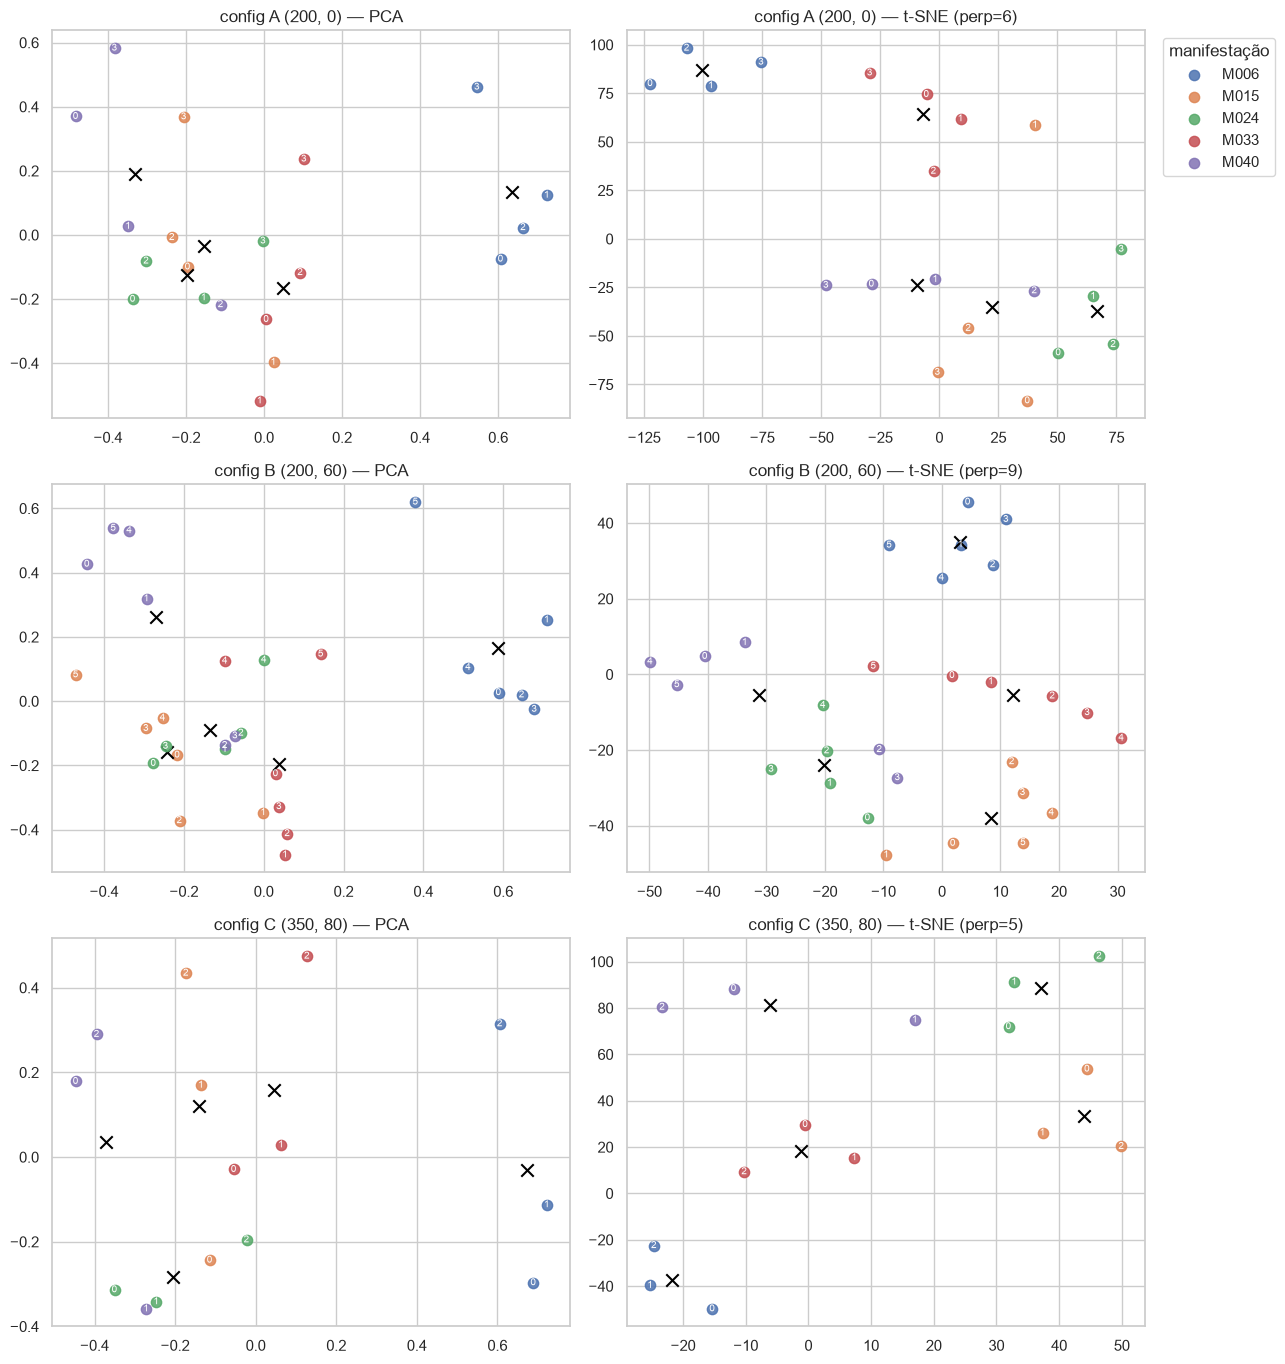

In [7]:
def plotar_2d(config, ax_pca, ax_tsne):
    g = chunks[chunks.config == config].reset_index(drop=True)
    X = np.vstack(g["emb"].values)
    pca = PCA(n_components=2, random_state=0).fit_transform(X)
    perp = max(2, min(10, len(g) // 3))
    tsne = TSNE(n_components=2, perplexity=perp, random_state=0, init="pca").fit_transform(X)
    for nome, proj, ax in [("PCA", pca, ax_pca), (f"t-SNE (perp={perp})", tsne, ax_tsne)]:
        for mid, gg in g.groupby("id"):
            pts = proj[gg.index]
            ax.scatter(pts[:, 0], pts[:, 1], label=mid, s=55, alpha=0.85)
            for (x, y), k in zip(pts, gg["k"]):
                ax.annotate(str(k), (x, y), fontsize=7, ha="center", va="center", color="white")
            cx, cy = pts.mean(axis=0)
            ax.scatter(cx, cy, marker="x", s=80, color="black")
        ax.set_title(f"config {config} {CONFIGS[config]} — {nome}")
    sil = silhouette_score(X, g["id"], metric="cosine") if g["id"].nunique() > 1 else np.nan
    return sil

fig, axes = plt.subplots(len(CONFIGS), 2, figsize=(13, 4.6 * len(CONFIGS)))
silhuetas = {}
for (nome, _), (ax_p, ax_t) in zip(CONFIGS.items(), axes):
    silhuetas[nome] = plotar_2d(nome, ax_p, ax_t)
axes[0, 1].legend(title="manifestação", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig("resultados/chunks_2d.png", dpi=120)

pd.Series(silhuetas, name="silhueta (cos) por manifestação").round(3)

### Pergunta 3: os chunks de uma mesma manifestação ficam próximos?

Os pontos são chunks, a cor é a manifestação de origem, o número é a posição do chunk dentro do texto e o "x" é o centróide. Para não depender só do olho, o coeficiente de **silhueta** (com a manifestação como rótulo de cluster) resume quão bem os chunks se agrupam pela origem: valores acima de ~0.2 já indicam agrupamento perceptível; perto de zero, chunks misturados.

O padrão esperado e observado: chunks da mesma denúncia formam grupos, mas não são compactos. Os primeiros chunks (que apresentam o problema) ficam próximos entre si e do centróide; os últimos (que contêm o pedido genérico, "solicitamos providências", "pedimos fiscalização") tendem a se afastar do grupo de origem e a se aproximar dos chunks finais de *outras* manifestações, porque o conteúdo "pedido à prefeitura" é semanticamente parecido em todas. Isso é visível como pontos com número alto perto dos pontos de número alto de outras cores.

Configurações com chunks maiores (C) tendem a agrupar melhor (silhueta maior) porque cada chunk carrega mais contexto da denúncia original; chunks pequenos e sem overlap (A) são os mais dispersos. O t-SNE exagera a separação visual em relação ao PCA e deve ser lido só qualitativamente.

## 4. Persistência dos resultados

In [8]:
resultados = {
    "modelo": MODELO,
    "max_seq_length": int(modelo.max_seq_length),
    "manifestacoes_longas": longas[["id", "n_chars", "n_tokens"]].to_dict(orient="records"),
    "configs": {k: {"chunk_size": v[0], "chunk_overlap": v[1]} for k, v in CONFIGS.items()},
    "resumo_chunks": resumo.to_dict(orient="index"),
    "coesao": tabela_coesao.to_dict(orient="index"),
    "silhueta": {k: (None if np.isnan(v) else float(v)) for k, v in silhuetas.items()},
    "exemplo_id": EXEMPLO,
    "exemplo_chunks": {nome: chunks[(chunks.config == nome) & (chunks.id == EXEMPLO)]["chunk"].tolist() for nome in CONFIGS},
}
with open("resultados/entrega3.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print("salvo em resultados/entrega3.json")

salvo em resultados/entrega3.json
